# Split Factor with Tail Example: Convergence Analysis

This notebook compares convergence behavior between:

**Scenario 1: Splitting + Damping**
- 3 variable nodes: X1, X2, X3
- Split factors F12' and F12'' (symmetric split) with cost table [[4,10],[16,8]]
- Tail factor F23 (unary constraint) that always sends 10 to X2

**Scenario 2: Damping Only (No Splitting)**
- Factor F12 with full cost table [[8,20],[32,16]]
- Same F23 tail factor

We analyze when the message passes the threshold k=8 to converge to state (b, b).
We use **RDampingEngine** in both cases to dampen the R-messages (Factor -> Variable), specifically affecting the messages from F23.

In [13]:
import numpy as np
import math
import matplotlib.pyplot as plt

from propflow import FactorAgent, VariableAgent
from propflow.core.components import CostTable
from propflow.policies.splitting import split_specific_factors
from propflow.utils.fg_utils import FGBuilder
from propflow.bp.engine_base import BPEngine
from propflow.bp.engines import DampingEngine, RDampingEngine
from propflow.snapshots import SnapshotVisualizer

## Convergence Theory

With damping factor $\lambda$, messages evolve as:
$$m^{(t)} = \lambda \cdot m^{(t-1)} + (1-\lambda) \cdot m_{\text{new}}$$

For a message converging to limit $L=10$, starting from **$m^{(0)} = 0$**:
$$m^{(t)} = 10 \cdot (1 - \lambda^t)$$

To find when message crosses threshold $k$:
$$t_{\min} = \left\lceil \frac{\ln\left(1 - \frac{k}{10}\right)}{\ln(\lambda)} \right\rceil$$

With $\lambda=0.5$:
$$t_{\min} = \left\lceil \log_{0.5}\left(1 - \frac{k}{10}\right) \right\rceil = \left\lceil \log_2\left(\frac{10}{10-k}\right) \right\rceil$$

In [14]:
def compute_t_min(m0: float, k: float, lam: float = 0.5) -> int:
    """Compute minimum iterations to cross threshold k starting from m0.
    
    Formula: t_min = ceil( log_2( (10 - m0) / (10 - k) ) )
    """
    if m0 >= k:
        return 0
    
    numerator = math.log((10 - m0) / (10 - k))
    denominator = math.log(1 / lam)
    return math.ceil(numerator / denominator)


def damped_message(m0: float, t: int, lam: float = 0.5, limit: float = 10.0) -> float:
    """Compute message value at iteration t with damping."""
    return limit + (lam ** t) * (m0 - limit)


# test the formulas for m0 = 0
m0 = 0.0
k = 8.0
lam = 0.5
limit = 10.0

t_min = compute_t_min(m0, k, lam)
msg_val = damped_message(m0, t_min, lam, limit)

print("=== Convergence Formula Verification ===")
print(f"Parameters: m0={m0}, k={k}, lambda={lam}, limit={limit}")
print(f"Predicted t_min: {t_min}")
print(f"Message at t={t_min}: {msg_val:.4f}")

=== Convergence Formula Verification ===
Parameters: m0=0.0, k=8.0, lambda=0.5, limit=10.0
Predicted t_min: 3
Message at t=3: 8.7500


---
## Scenario 1: Splitting + Damping

- Split factors F12', F12'' each with cost table [[4,10],[16,8]]
- F23 sends constant 10 to X2
- Threshold k=8 for converging to (b,b)

Scenario 1: Splitting + Damping
Split factors each have cost table:
[[ 4 16]
 [10  8]]


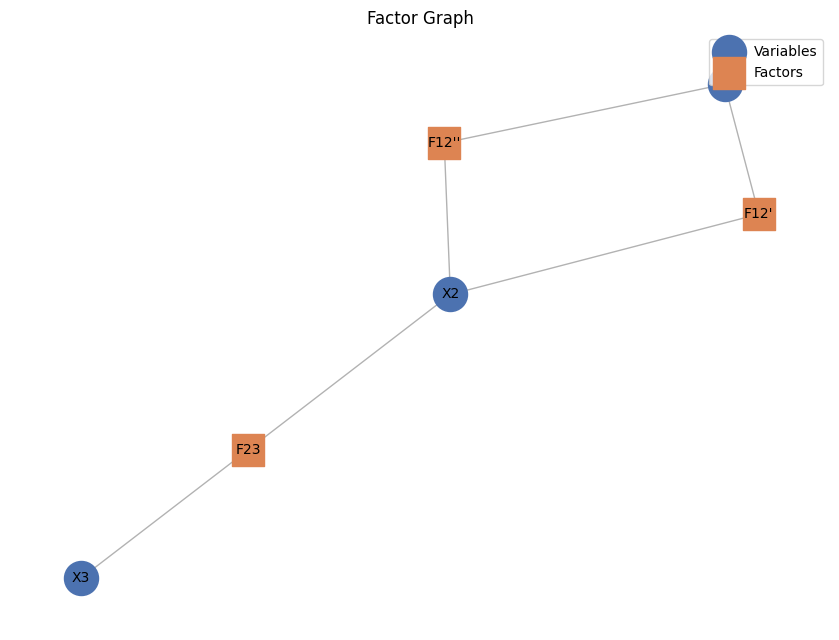

In [15]:
# scenario 1: splitting + damping
# each split factor has half the cost: [[4,10],[16,8]]

C12_split: CostTable = np.array([[4, 10],
                                  [16, 8]]).T

# unary constraint F23: designed to send constant 10 to X2
C23_unary: CostTable = np.array([[10, 10], [0, 10]]) # User defined binary table

# create variable nodes
X1_s1 = VariableAgent("X1", domain=2)
X2_s1 = VariableAgent("X2", domain=2)
X3_s1 = VariableAgent("X3", domain=2)


# create factor for X1-X2 (will be split)
F12_s1 = FactorAgent.create_from_cost_table("F12", cost_table=C12_split * 2)  # full cost before split

# create unary factor for X2-X3 
F23_s1 = FactorAgent.create_from_cost_table("F23", cost_table=C23_unary)

# build factor graph
fg_split = FGBuilder.build_from_edges(
    variables=[X1_s1, X2_s1, X3_s1],
    factors=[F12_s1, F23_s1],
    edges={F12_s1: [X1_s1, X2_s1], F23_s1: [X2_s1, X3_s1]},
)

# apply symmetric splitting to F12
split_specific_factors(fg_split, [F12_s1])

print("Scenario 1: Splitting + Damping")
print("Split factors each have cost table:")
print(C12_split)
fg_split.visualize(pretty=True)

Scenario 1: Ran 25 iterations with damping_factor=0.5


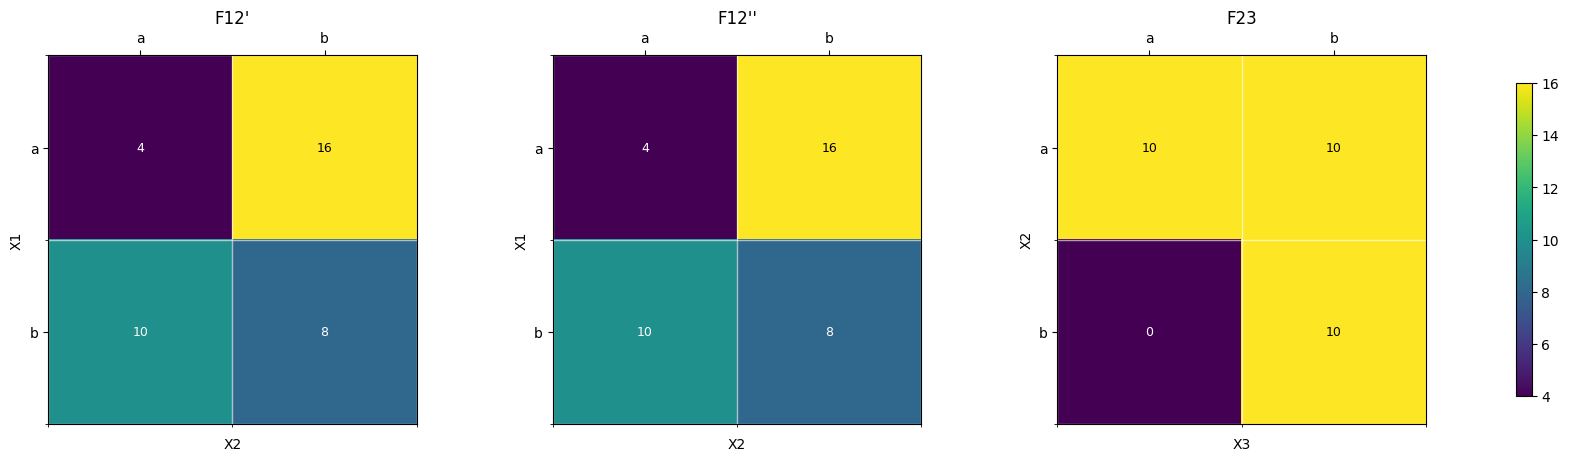

In [16]:
# run BP with R-damping on the split graph
damping_factor = 0.5
# Using RDampingEngine to damp messages from factors (specifically F23)
engine_split = RDampingEngine(factor_graph=fg_split, use_bct_history=True, damping_factor=damping_factor)

# run for several iterations and track messages
num_iterations = 25
for i in range(num_iterations):
    engine_split.step(i)

print(f"Scenario 1: Ran {num_iterations} iterations with damping_factor={damping_factor}")

# visualize cost tables
viz_split = SnapshotVisualizer(engine_split.snapshots)
viz_split.plot_cost_tables(show=False)

---
## Scenario 2: Damping Only (No Splitting)

- Single factor F12 with cost table [[8,20],[32,16]]
- Same F23 unary constraint

Scenario 2: Damping Only (No Splitting)
Single factor F12 with cost table:
[[ 8 32]
 [20 16]]


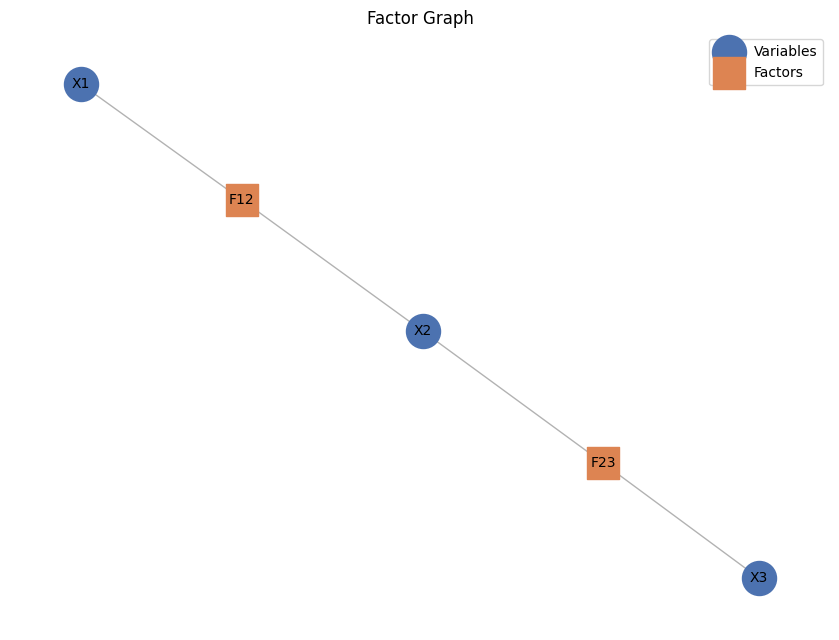

In [17]:
# scenario 2: damping only (no splitting)
# full cost table [[8,20],[32,16]]

C12_full: CostTable = np.array([[8, 20],
                                 [32, 16]]).T

# create variable nodes
X1_s2 = VariableAgent("X1", domain=2)
X2_s2 = VariableAgent("X2", domain=2)
X3_s2 = VariableAgent("X3", domain=2)


# create factor for X1-X2 (NOT split)
F12_s2 = FactorAgent.create_from_cost_table("F12", cost_table=C12_full)

# create unary factor for X2-X3
F23_s2 = FactorAgent.create_from_cost_table("F23", cost_table=C23_unary)

# build factor graph (no splitting)
fg_nosplit = FGBuilder.build_from_edges(
    variables=[X1_s2, X2_s2, X3_s2],
    factors=[F12_s2, F23_s2],
    edges={F12_s2: [X1_s2, X2_s2], F23_s2: [X2_s2, X3_s2]},
)

print("Scenario 2: Damping Only (No Splitting)")
print("Single factor F12 with cost table:")
print(C12_full)
fg_nosplit.visualize(pretty=True)

Scenario 2: Ran 25 iterations with damping_factor=0.5


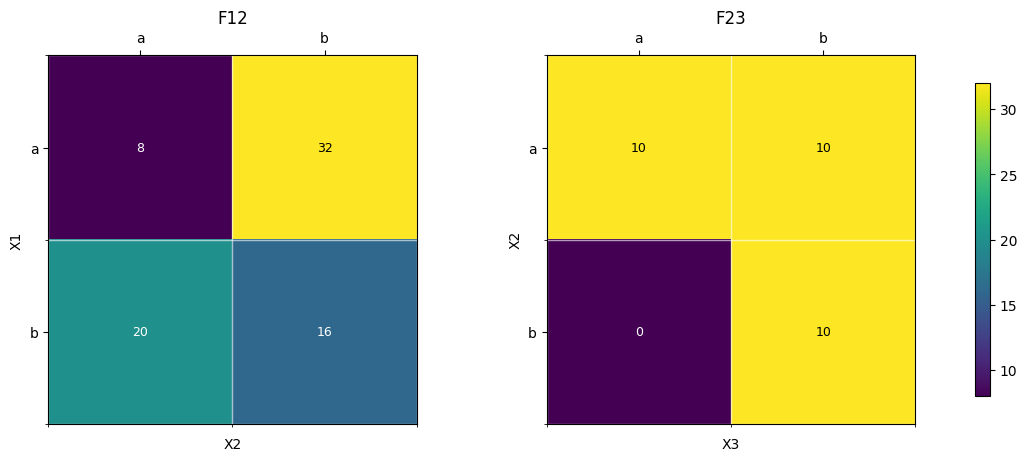

In [18]:
engine_nosplit = RDampingEngine(factor_graph=fg_nosplit, use_bct_history=True, damping_factor=damping_factor)
for i in range(num_iterations):
    engine_nosplit.step(i)

print(f"Scenario 2: Ran {num_iterations} iterations with damping_factor={damping_factor}")

viz_nosplit = SnapshotVisualizer(engine_nosplit.snapshots)
viz_nosplit.plot_cost_tables(show=False)

---
## Scenario 3: Splitting Only (No Damping)

- Split factors F12', F12''
- No damping (lambda=0.0)


In [19]:
# Scenario 3: Splitting Only (No Damping)
print("Scenario 3: Splitting Only")

# Reuse factor graph structure from Scenario 1 if possible, but simplest to rebuild
X1_s3 = VariableAgent("X1", domain=2)
X2_s3 = VariableAgent("X2", domain=2)
X3_s3 = VariableAgent("X3", domain=2)


F12_s3 = FactorAgent.create_from_cost_table("F12", cost_table=C12_split * 2)
F23_s3 = FactorAgent.create_from_cost_table("F23", cost_table=C23_unary)

fg_s3 = FGBuilder.build_from_edges(
    variables=[X1_s3, X2_s3, X3_s3],
    factors=[F12_s3, F23_s3],
    edges={F12_s3: [X1_s3, X2_s3], F23_s3: [X2_s3, X3_s3]},
)
split_specific_factors(fg_s3, [F12_s3])

engine_s3 = RDampingEngine(factor_graph=fg_s3, use_bct_history=True, damping_factor=0.0)
for i in range(num_iterations):
    engine_s3.step(i)

print(f"Scenario 3 Ran {num_iterations} iterations")


Scenario 3: Splitting Only
Scenario 3 Ran 25 iterations


---
## Scenario 4: Baseline (No Splitting, No Damping)

- Single factor F12
- No damping


In [20]:
# Scenario 4: Baseline
print("Scenario 4: Baseline")

X1_s4 = VariableAgent("X1", domain=2)
X2_s4 = VariableAgent("X2", domain=2)
X3_s4 = VariableAgent("X3", domain=2)


F12_s4 = FactorAgent.create_from_cost_table("F12", cost_table=C12_full)
F23_s4 = FactorAgent.create_from_cost_table("F23", cost_table=C23_unary)

fg_s4 = FGBuilder.build_from_edges(
    variables=[X1_s4, X2_s4, X3_s4],
    factors=[F12_s4, F23_s4],
    edges={F12_s4: [X1_s4, X2_s4], F23_s4: [X2_s4, X3_s4]},
)

engine_s4 = RDampingEngine(factor_graph=fg_s4, use_bct_history=True, damping_factor=0.0)
for i in range(num_iterations):
    engine_s4.step(i)

print(f"Scenario 4 Ran {num_iterations} iterations")


Scenario 4: Baseline
Scenario 4 Ran 25 iterations


---
## Convergence Analysis

Comparing belief convergence (X1[1]-X1[0]) across all 4 scenarios.


Scenarios 5 & 6 Ran 25 iterations


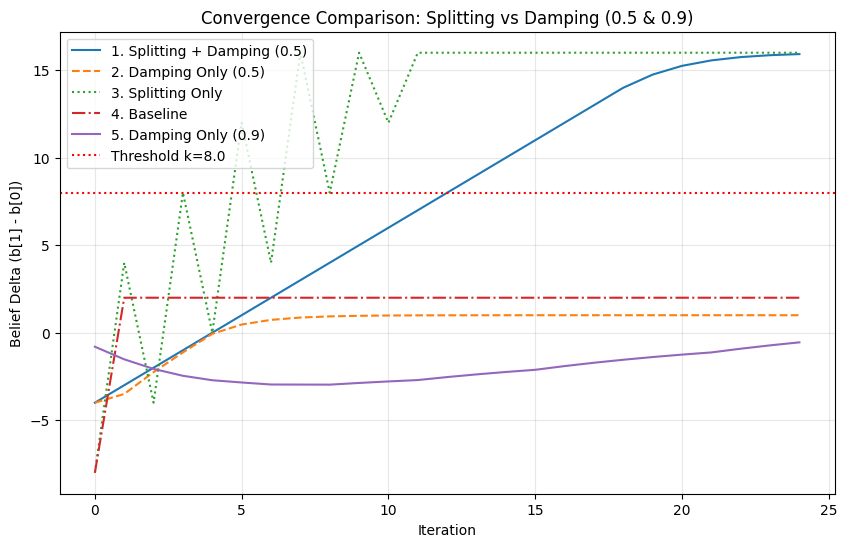

In [21]:
def extract_belief_diffs(engine) -> list[float]:
    '''Extract Belief difference (belief[1] - belief[0]) at X1 for each iteration.'''
    diffs = []
    
    for snap in engine.snapshots:
        if 'X1' in snap.beliefs:
            b = snap.beliefs['X1']
            diffs.append(b[0] - b[1])
        else:
            diffs.append(0.0)
    return diffs

# Scenario 5: Damping Only (0.9)
X1_s5 = VariableAgent("X1", domain=2)
X2_s5 = VariableAgent("X2", domain=2)
X3_s5 = VariableAgent("X3", domain=2)
F12_s5 = FactorAgent.create_from_cost_table("F12", cost_table=C12_full)
F23_s5 = FactorAgent.create_from_cost_table("F23", cost_table=C23_unary)

fg_s5 = FGBuilder.build_from_edges(
    variables=[X1_s5, X2_s5, X3_s5],
    factors=[F12_s5, F23_s5],
    edges={F12_s5: [X1_s5, X2_s5], F23_s5: [X2_s5, X3_s5]},
)

engine_s5 = RDampingEngine(factor_graph=fg_s5, use_bct_history=True, damping_factor=0.9)
for i in range(num_iterations):
    engine_s5.step(i)

# Scenario 6: Splitting + Damping (0.9)
# X1_s6 = VariableAgent("X1", domain=2)
# X2_s6 = VariableAgent("X2", domain=2)
# X3_s6 = VariableAgent("X3", domain=2)
# F12_s6 = FactorAgent.create_from_cost_table("F12", cost_table=C12_full)
# F23_s6 = FactorAgent.create_from_cost_table("F23", cost_table=C23_unary)

# fg_s6 = FGBuilder.build_from_edges(
#     variables=[X1_s6, X2_s6, X3_s6],
#     factors=[F12_s6, F23_s6],
#     edges={F12_s6: [X1_s6, X2_s6], F23_s6: [X2_s6, X3_s6]},
# )
# Apply symmetric splitting to F12 (same as Scenario 1)
# split_specific_factors(fg_s6, [F12_s6])

# engine_s6 = RDampingEngine(factor_graph=fg_s6, use_bct_history=True, damping_factor=0.9)
# for i in range(num_iterations):
#     engine_s6.step(i)

print(f"Scenarios 5 & 6 Ran {num_iterations} iterations")

q_scen1 = extract_belief_diffs(engine_split)   # Split+Damp (0.5)
q_scen2 = extract_belief_diffs(engine_nosplit) # Damp Only (0.5)
q_scen3 = extract_belief_diffs(engine_s3)      # Split Only
q_scen4 = extract_belief_diffs(engine_s4)      # Baseline
q_scen5 = extract_belief_diffs(engine_s5)      # Damp Only (0.9)
# q_scen6 = extract_belief_diffs(engine_s6)      # Split+Damp (0.9)

plt.figure(figsize=(10, 6))
x_range = range(num_iterations)
plt.plot(x_range, q_scen1, '-', label="1. Splitting + Damping (0.5)")
plt.plot(x_range, q_scen2, '--', label="2. Damping Only (0.5)")
plt.plot(x_range, q_scen3, ':', label="3. Splitting Only")
plt.plot(x_range, q_scen4, '-.', label="4. Baseline")
plt.plot(x_range, q_scen5, '-', label="5. Damping Only (0.9)")
# plt.plot(x_range, q_scen6, '-', label="6. Splitting + Damping (0.9)")

plt.axhline(y=k, color='r', linestyle=':', label=f"Threshold k={k}")
plt.title("Convergence Comparison: Splitting vs Damping (0.5 & 0.9)")
plt.xlabel("Iteration")
plt.ylabel("Belief Delta (b[1] - b[0])")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
def print_messages(engine):
    for i, snap in enumerate(engine.snapshots):
        print(f"Snapshot {i}:")
        print(f"Q messages: {snap.Q}")
        print(f"R messages: {snap.R}")
print_messages(engine_split)

Snapshot 0:
Q messages: {
  X1 -> F12': [0., 0.]
  X1 -> F12'': [0., 0.]
  X2 -> F12': [0., 0.]
  X2 -> F12'': [0., 0.]
  X2 -> F23: [0., 0.]
  X3 -> F23: [0., 0.]
}
R messages: {
  F12' -> X1: [2., 4.]
  F12' -> X2: [2., 4.]
  F12'' -> X1: [2., 4.]
  F12'' -> X2: [2., 4.]
  F23 -> X2: [5., 0.]
  F23 -> X3: [0., 5.]
}
Snapshot 1:
Q messages: {
  X1 -> F12': [0., 2.]
  X1 -> F12'': [0., 2.]
  X2 -> F12': [3., 0.]
  X2 -> F12'': [3., 0.]
  X2 -> F23: [0., 4.]
  X3 -> F23: [0., 0.]
}
R messages: {
  F12' -> X1: [6.5, 8. ]
  F12' -> X2: [4., 8.]
  F12'' -> X1: [6.5, 8. ]
  F12'' -> X2: [4., 8.]
  F23 -> X2: [7.5, 0. ]
  F23 -> X3: [4. , 9.5]
}
Snapshot 2:
Q messages: {
  X1 -> F12': [0. , 1.5]
  X1 -> F12'': [0. , 1.5]
  X2 -> F12': [3.5, 0. ]
  X2 -> F12'': [3.5, 0. ]
  X2 -> F23: [0., 8.]
  X3 -> F23: [0., 0.]
}
R messages: {
  F12' -> X1: [11., 12.]
  F12' -> X2: [ 7.25, 12.  ]
  F12'' -> X1: [11., 12.]
  F12'' -> X2: [ 7.25, 12.  ]
  F23 -> X2: [8.75, 0.  ]
  F23 -> X3: [10.  , 13.75]
